In [ ]:
# 1. Data Cleaning

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("car_data.csv")

In [4]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        892 non-null    str  
 1   company     892 non-null    str  
 2   year        892 non-null    str  
 3   Price       892 non-null    str  
 4   kms_driven  840 non-null    str  
 5   fuel_type   837 non-null    str  
dtypes: str(6)
memory usage: 92.3 KB


In [6]:
df["year"] = pd.to_numeric(df["year"], errors= "coerce")   # float
df.dropna(subset = ["year"], inplace = True) 
df["year"] = df["year"].astype(int)

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        842 non-null    str  
 1   company     842 non-null    str  
 2   year        842 non-null    int64
 3   Price       842 non-null    str  
 4   kms_driven  840 non-null    str  
 5   fuel_type   837 non-null    str  
dtypes: int64(1), str(5)
memory usage: 91.4 KB


In [8]:
df["Price"] = df["Price"].str.replace(",","")
df["Price"] = pd.to_numeric(df["Price"], errors= "coerce")
df.dropna(subset = ["Price"], inplace = True)
df["Price"] = df["Price"].astype(int)

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        819 non-null    str  
 1   company     819 non-null    str  
 2   year        819 non-null    int64
 3   Price       819 non-null    int64
 4   kms_driven  819 non-null    str  
 5   fuel_type   816 non-null    str  
dtypes: int64(2), str(4)
memory usage: 82.4 KB


In [10]:
df["kms_driven"] = df["kms_driven"].str.replace(",","").str.replace(" kms","")
df["kms_driven"] = pd.to_numeric(df["kms_driven"], errors= "coerce")
df.dropna(subset = ["kms_driven"], inplace = True)
df["kms_driven"] = df["kms_driven"].astype(int)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        817 non-null    str  
 1   company     817 non-null    str  
 2   year        817 non-null    int64
 3   Price       817 non-null    int64
 4   kms_driven  817 non-null    int64
 5   fuel_type   816 non-null    str  
dtypes: int64(3), str(3)
memory usage: 74.2 KB


In [12]:
df.dropna(subset = ["fuel_type"], inplace = True)
df.info()

<class 'pandas.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        816 non-null    str  
 1   company     816 non-null    str  
 2   year        816 non-null    int64
 3   Price       816 non-null    int64
 4   kms_driven  816 non-null    int64
 5   fuel_type   816 non-null    str  
dtypes: int64(3), str(3)
memory usage: 74.1 KB


In [13]:
df.duplicated().value_counts()
df = df.drop_duplicates()

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 724 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        724 non-null    str  
 1   company     724 non-null    str  
 2   year        724 non-null    int64
 3   Price       724 non-null    int64
 4   kms_driven  724 non-null    int64
 5   fuel_type   724 non-null    str  
dtypes: int64(3), str(3)
memory usage: 65.8 KB


In [15]:
for i in df.index:
    name = df.loc[i,"name"]
    company = df.loc[i,"company"]
    name = name.replace(company+" ","")
    name = ' '.join(name.split()[0:3])
    df.loc[i,"name"] = name

In [16]:
df

,name,company,year,Price,kms_driven,fuel_type
0,Santro Xing XO,Hyundai,2007,80000,45000,Petrol
1,Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Grand i10 Magna,Hyundai,2014,325000,28000,Petrol
4,EcoSport Titanium 1.5L,Ford,2014,575000,36000,Diesel
6,Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
883,Suzuki Ritz VXI,Maruti,2011,270000,50000,Petrol
885,Indica V2 DLE,Tata,2009,110000,30000,Diesel
886,Corolla Altis,Toyota,2009,300000,132000,Petrol
888,Zest XM Diesel,Tata,2018,260000,27000,Diesel


In [17]:
df.to_csv("cleaned_car_data.csv", index = False)

In [ ]:
# 2. EDA

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("cleaned_car_data.csv")

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        724 non-null    str  
 1   company     724 non-null    str  
 2   year        724 non-null    int64
 3   Price       724 non-null    int64
 4   kms_driven  724 non-null    int64
 5   fuel_type   724 non-null    str  
dtypes: int64(3), str(3)
memory usage: 51.9 KB


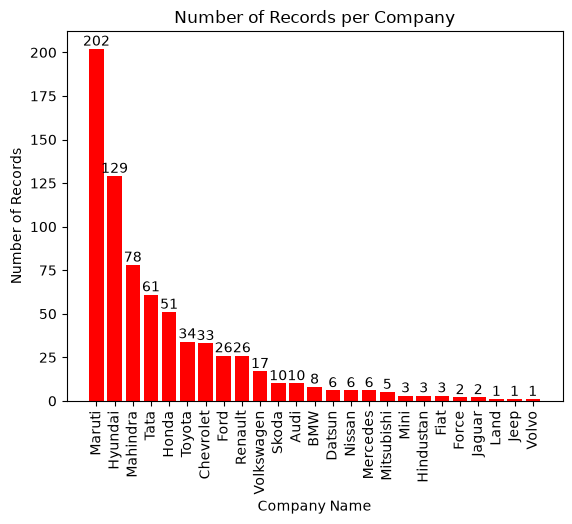

In [21]:
company_counts  = df['company'].value_counts()
company_counts
fig, ax = plt.subplots()

plt.xlabel('Company Name')
plt.ylabel('Number of Records')
plt.title('Number of Records per Company')

bars = ax.bar(company_counts.index, company_counts.values, color='red')
ax.bar_label(bars)
plt.xticks(rotation=90)
plt.show()

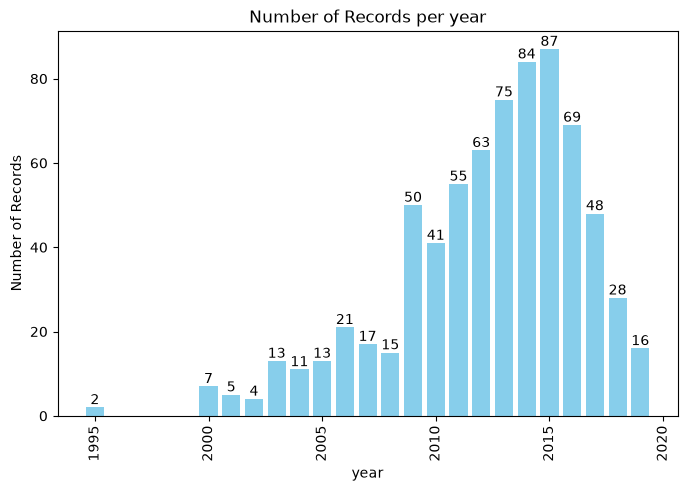

In [22]:
year_counts  = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize= (8,5))

plt.xlabel('year')
plt.ylabel('Number of Records')
plt.title('Number of Records per year')

bars = ax.bar(year_counts.index, year_counts.values, color='skyblue')
ax.bar_label(bars)
plt.xticks(rotation=90)
plt.show()

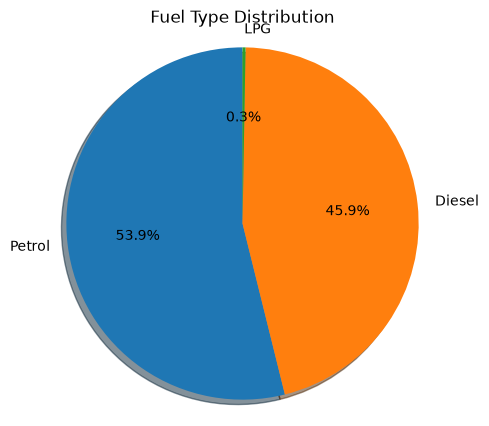

In [23]:
fuel_counts  = df['fuel_type'].value_counts()
plt.figure(figsize = (5,5))
plt.pie(
    fuel_counts.values,
    labels = fuel_counts.index,
    autopct = '%1.1f%%',
    startangle = 90,
    shadow = True,
)
plt.axis('equal')
plt.title("Fuel Type Distribution")
plt.show()

In [24]:
table = pd.crosstab(df['company'], df['fuel_type'], margins=True, margins_name='Total')
print(table)

fuel_type   Diesel  LPG  Petrol  Total
company                               
Audi             7    0       3     10
BMW              5    0       3      8
Chevrolet       20    0      13     33
Datsun           0    0       6      6
Fiat             1    0       2      3
Force            2    0       0      2
Ford            16    0      10     26
Hindustan        2    0       1      3
Honda           12    0      39     51
Hyundai         25    0     104    129
Jaguar           1    0       1      2
Jeep             1    0       0      1
Land             1    0       0      1
Mahindra        75    0       3     78
Maruti          55    2     145    202
Mercedes         2    0       4      6
Mini             0    0       3      3
Mitsubishi       3    0       2      5
Nissan           3    0       3      6
Renault         18    0       8     26
Skoda            7    0       3     10
Tata            46    0      15     61
Toyota          18    0      16     34
Volkswagen      11    0  

In [25]:
bins = [0, 500000, 1000000, 1500000, 2000000, 3000000, 5000000, 10000000]

labels = [
    '0 - 5 Lakh',
    '5 - 10 Lakh',
    '10 - 15 Lakh',
    '15 - 20 Lakh',
    '20 - 30 Lakh',
    '30 - 50 Lakh',
    '50 Lakh - 1 Cr'
]

df['group'] = pd.cut(df['Price'], bins=bins, labels=labels, right=True)

In [26]:
pd.crosstab(df['group'], df['company'])
df['group'].value_counts()

group
0 - 5 Lakh        561
5 - 10 Lakh       125
10 - 15 Lakh       19
15 - 20 Lakh       12
20 - 30 Lakh        5
30 - 50 Lakh        1
50 Lakh - 1 Cr      1
Name: count, dtype: int64

C:\Users\sharv\AppData\Local\Temp\ipykernel_10884\624815975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='company', y='Price', palette='Set2')


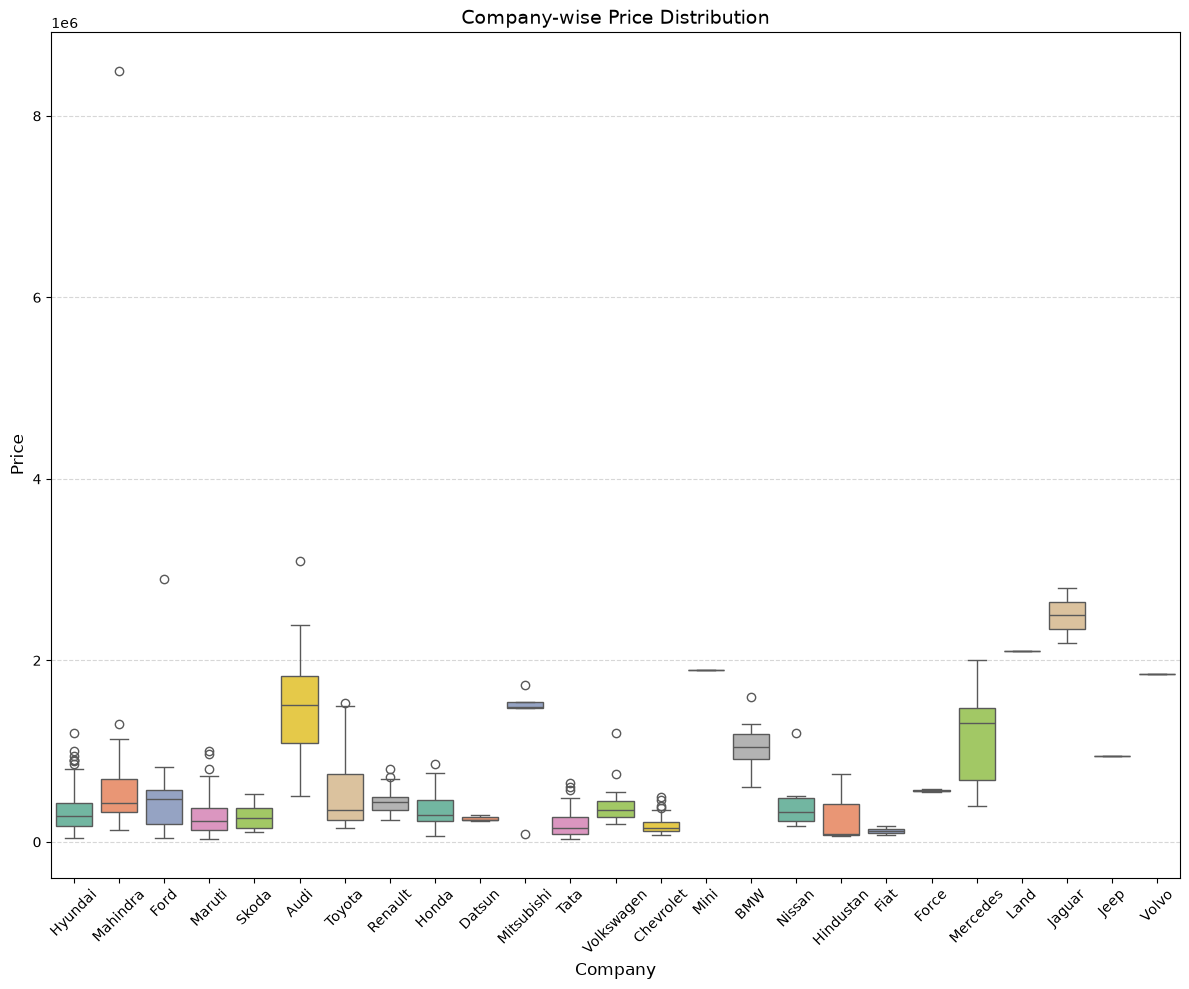

In [27]:
plt.figure(figsize=(12,10))
sns.boxplot(data=df, x='company', y='Price', palette='Set2')

plt.title('Company-wise Price Distribution', fontsize=14)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [28]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df_clean = df[(df['Price'] >= lower_bound)&(df['Price'] <= upper_bound)]

In [29]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 679 entries, 0 to 723
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   name        679 non-null    str     
 1   company     679 non-null    str     
 2   year        679 non-null    int64   
 3   Price       679 non-null    int64   
 4   kms_driven  679 non-null    int64   
 5   fuel_type   679 non-null    str     
 6   group       679 non-null    category
dtypes: category(1), int64(3), str(3)
memory usage: 55.3 KB


In [30]:
df_clean.drop(columns = ['group'] , inplace = True)

In [31]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 679 entries, 0 to 723
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        679 non-null    str  
 1   company     679 non-null    str  
 2   year        679 non-null    int64
 3   Price       679 non-null    int64
 4   kms_driven  679 non-null    int64
 5   fuel_type   679 non-null    str  
dtypes: int64(3), str(3)
memory usage: 54.2 KB


In [32]:
df_clean.to_csv("final_cleaned_dataset.csv", index = False)

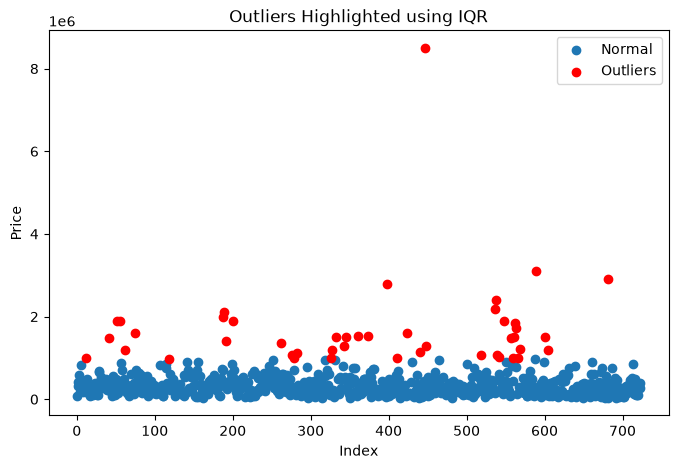

In [33]:
import matplotlib.pyplot as plt

# Step 1: Calculate IQR 
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 2: Separate normal & outliers
normal_data = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

# Step 3: Scatter Plot
plt.figure(figsize=(8,5))

# Normal points
plt.scatter(normal_data.index, normal_data['Price'], label='Normal')

# Outliers (highlight in red)
plt.scatter(outliers.index, outliers['Price'], color='red', label='Outliers')

plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Outliers Highlighted using IQR")
plt.legend()
plt.show()

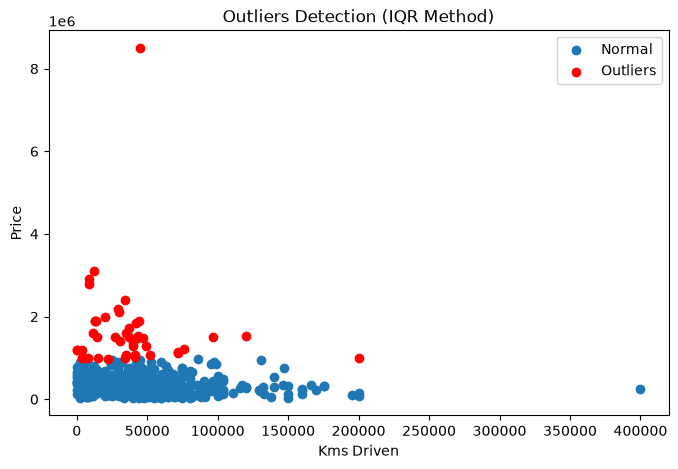

In [34]:
import matplotlib.pyplot as plt

# Step 1: IQR Calculation
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 2: Separate Data
normal_data = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

# Step 3: Scatter Plot
plt.figure(figsize=(8,5))

# Normal data
plt.scatter(normal_data['kms_driven'], normal_data['Price'], label='Normal')

# Outliers (highlighted)
plt.scatter(outliers['kms_driven'], outliers['Price'], color='red', label='Outliers')

# Labels & Title
plt.xlabel("Kms Driven")
plt.ylabel("Price")
plt.title("Outliers Detection (IQR Method)")
plt.legend()
plt.show()

In [ ]:
# 3. Implementation

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("final_cleaned_dataset.csv")

In [3]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Santro Xing XO,Hyundai,2007,80000,45000,Petrol
1,Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
2,Grand i10 Magna,Hyundai,2014,325000,28000,Petrol
3,EcoSport Titanium 1.5L,Ford,2014,575000,36000,Diesel
4,Figo,Ford,2012,175000,41000,Diesel


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        679 non-null    str  
 1   company     679 non-null    str  
 2   year        679 non-null    int64
 3   Price       679 non-null    int64
 4   kms_driven  679 non-null    int64
 5   fuel_type   679 non-null    str  
dtypes: int64(3), str(3)
memory usage: 48.7 KB


In [6]:
X = df[["year"]]

y = df["Price"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
model = LinearRegression()

In [9]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[24267.39]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.851e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
y_pred = model.predict(X_test)

In [11]:
r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)

R2 Score : 0.26037204204483155


In [12]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE :", mae)

MAE : 140109.54225632164


In [14]:
mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)

MSE : 35289233191.62702


In [15]:
rmse = np.sqrt(mse)
print("RMSE :", rmse)

RMSE : 187854.28712602495


In [16]:
new_year = pd.DataFrame({
    "year": [2020]
})

prediction = model.predict(new_year)

print("Predicted Price :", prediction[0])

Predicted Price : 506960.2928525135


In [17]:
joblib.dump(model, "simple_linear_regression_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
